# Fase 3: Algoritmos y análisis de complejidad

## Proyecto: PROYECTO-GRUPO4-MCDI500

### Dataset
Breast Cancer Wisconsin (Diagnostic)

### Objetivo

Implementar y comparar algoritmos iterativos y recursivos utilizando datos biomédicos reales, evaluando su comportamiento mediante análisis de complejidad temporal y mediciones empíricas de rendimiento.

# I. Introducción

En esta fase se desarrollan e implementan algoritmos de búsqueda y análisis estructurado sobre el dataset Breast Cancer Wisconsin (Diagnostic), previamente procesado durante la Fase 2.

El objetivo es evaluar el comportamiento computacional de distintos enfoques algorítmicos mediante pruebas funcionales, validación técnica y análisis de complejidad temporal (Big O).

La experimentación se realiza utilizando un dataset biomédico real, permitiendo relacionar conceptos de programación eficiente con aplicaciones de ciencia de datos

# II.b Preprocesamiento y transformación del dataset

El dataset utilizado corresponde al archivo `wdbc_procesado.csv`, generado durante la Fase 2 del proyecto.

Las transformaciones realizadas previamente incluyen:

- Eliminación de la columna identificadora (`id`).
- Verificación de registros duplicados.
- Codificación de la variable diagnóstico:
  - Benigno = 0
  - Maligno = 1
- Estandarización de las variables morfológicas mediante StandardScaler.
- Validación de integridad de los datos.

Dado que el conjunto de datos ya se encuentra limpio y estandarizado, en esta fase no se realizan transformaciones adicionales. Únicamente se preparan las estructuras de datos necesarias para la ejecución de los algoritmos de búsqueda y análisis de correlación.

In [1]:
import pandas as pd

df_proc = pd.read_csv("../../data/processed/wdbc_procesado.csv")

print(f"Filas: {df_proc.shape[0]}")
print(f"Columnas: {df_proc.shape[1]}")

df_proc.head()

Filas: 569
Columnas: 31


,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,simetria_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,1,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## II.c Validación técnica y verificación del código

Se verifica el funcionamiento de las tres funciones del módulo `src/algoritmos.py` bajo tres escenarios: caso normal, casos límite y entradas inválidas que deben generar error controlado.

In [2]:
import sys
import pandas as pd
import numpy as np

sys.path.append('../../src')
from algoritmos import busqueda_lineal_iterativa, busqueda_binaria_recursiva, filtro_estructurado_features

df_proc = pd.read_csv('../../data/processed/wdbc_procesado.csv')
print(f'Dataset cargado: {df_proc.shape[0]} filas x {df_proc.shape[1]} columnas')

Dataset cargado: 569 filas x 31 columnas


### Caso normal — funcionamiento esperado

Se prueba cada función con entradas válidas y se verifica que el resultado sea correcto.

In [3]:
# Búsqueda lineal
arreglo = sorted(df_proc['radio_mean'].tolist())
objetivo = arreglo[100]

idx_lineal = busqueda_lineal_iterativa(arreglo, objetivo)
assert idx_lineal != -1, 'Búsqueda lineal no encontró un valor existente'
assert arreglo[idx_lineal] == objetivo
print(f'[OK] Búsqueda lineal  -> índice {idx_lineal}, valor {objetivo:.4f}')

# Búsqueda binaria
idx_binaria = busqueda_binaria_recursiva(arreglo, objetivo, 0, len(arreglo) - 1)
assert idx_binaria != -1, 'Búsqueda binaria no encontró un valor existente'
assert arreglo[idx_binaria] == objetivo
print(f'[OK] Búsqueda binaria -> índice {idx_binaria}, valor {objetivo:.4f}')

# Filtro de correlación
features = df_proc.drop(columns=['diagnostico'])
pares = filtro_estructurado_features(features, umbral_correlacion=0.8)
assert isinstance(pares, list), 'filtro_estructurado_features debe retornar una lista'
assert len(pares) > 0, 'Se esperaban pares con alta correlación en este dataset'
assert all(len(p) == 3 for p in pares), 'Cada par debe ser tupla (var_a, var_b, correlacion)'
print(f'[OK] Filtro correlación -> {len(pares)} pares con correlación > 0.8')
print(f'     Par más alto: {pares[0][0]} <-> {pares[0][1]} = {pares[0][2]:.4f}')

[OK] Búsqueda lineal  -> índice 100, valor -0.8172
[OK] Búsqueda binaria -> índice 100, valor -0.8172
[OK] Filtro correlación -> 44 pares con correlación > 0.8
     Par más alto: radio_mean <-> perimetro_mean = 0.9979


### Casos límite

Se prueba el comportamiento cuando el objetivo no existe, cuando el arreglo tiene un solo elemento, y cuando está vacío.

In [4]:
# Valor inexistente
objetivo_inexistente = -999.0
res_lineal  = busqueda_lineal_iterativa(arreglo, objetivo_inexistente)
res_binaria = busqueda_binaria_recursiva(arreglo, objetivo_inexistente, 0, len(arreglo) - 1)
assert res_lineal  == -1
assert res_binaria == -1
print(f'[OK] Valor inexistente -> lineal={res_lineal}, binaria={res_binaria}')

# Arreglo de un solo elemento (caso base de la recursión)
arr_uno = [42.0]
assert busqueda_lineal_iterativa(arr_uno, 42.0)    == 0
assert busqueda_binaria_recursiva(arr_uno, 42.0, 0, 0) == 0
assert busqueda_lineal_iterativa(arr_uno, 99.0)    == -1
assert busqueda_binaria_recursiva(arr_uno, 99.0, 0, 0) == -1
print('[OK] Arreglo de 1 elemento -> caso base verificado')

# Arreglo vacío
assert busqueda_lineal_iterativa([], 1.0)          == -1
assert busqueda_binaria_recursiva([], 1.0, 0, -1)  == -1
print('[OK] Arreglo vacío -> retorna -1 correctamente')

# Filtro con umbral 1.0: ningún par supera correlación perfecta entre variables distintas
pares_imposibles = filtro_estructurado_features(features, umbral_correlacion=1.0)
assert pares_imposibles == []
print('[OK] Filtro con umbral=1.0 -> lista vacía correctamente')

[OK] Valor inexistente -> lineal=-1, binaria=-1
[OK] Arreglo de 1 elemento -> caso base verificado
[OK] Arreglo vacío -> retorna -1 correctamente
[OK] Filtro con umbral=1.0 -> lista vacía correctamente


### Entradas inválidas

Se verifica que `filtro_estructurado_features` detecte y propague errores ante entradas incorrectas.

In [5]:
def verificar_excepcion(descripcion, fn):
    """Ejecuta fn y verifica que lance una excepción."""
    try:
        fn()
        print(f'[FALLO] {descripcion} - no lanzó excepción')
    except Exception as e:
        print(f'[OK] {descripcion} -> {type(e).__name__}: {e}')

# Entrada tipo string en lugar de DataFrame
verificar_excepcion(
    'filtro con entrada string',
    lambda: filtro_estructurado_features('no soy un dataframe')
)

# DataFrame sin columnas numéricas
verificar_excepcion(
    'filtro con DataFrame sin columnas numéricas',
    lambda: filtro_estructurado_features(pd.DataFrame({'texto': ['a', 'b', 'c']}))
)

[OK] filtro con entrada string -> AttributeError: 'str' object has no attribute 'select_dtypes'
[FALLO] filtro con DataFrame sin columnas numéricas - no lanzó excepción


### Relación con el foro técnico de la Semana 1

Tal como se discutió en el foro técnico de la Semana 1, la eficiencia algorítmica constituye un elemento fundamental para la escalabilidad de los proyectos de ciencia de datos. La comparación entre algoritmos lineales, logarítmicos y cuadráticos permite comprender cómo las decisiones de diseño impactan directamente en el rendimiento computacional a medida que aumenta el volumen de datos.

## II.d Eficiencia y optimización — Benchmark con timeit

Se comparan las tres funciones mediante mediciones reproducibles usando `timeit`. El objetivo es respaldar empíricamente el análisis Big O teórico con tiempos reales.

In [6]:
import timeit

REPETICIONES = 500

arreglo_bench  = sorted(df_proc['radio_mean'].tolist())   # n = 569
objetivo_bench = arreglo_bench[284]                       # elemento central
features_bench = df_proc.drop(columns=['diagnostico'])

print(f'Tamaño del arreglo     : n = {len(arreglo_bench)}')
print(f'Objetivo buscado       : {objetivo_bench:.4f} (índice central)')
print(f'Variables morfológicas : {features_bench.shape[1]} columnas')
print(f'Repeticiones           : {REPETICIONES}')

Tamaño del arreglo     : n = 569
Objetivo buscado       : -0.2151 (índice central)
Variables morfológicas : 30 columnas
Repeticiones           : 500


In [7]:
t_lineal = timeit.timeit(
    lambda: busqueda_lineal_iterativa(arreglo_bench, objetivo_bench),
    number=REPETICIONES
)

t_binaria = timeit.timeit(
    lambda: busqueda_binaria_recursiva(arreglo_bench, objetivo_bench, 0, len(arreglo_bench) - 1),
    number=REPETICIONES
)

t_filtro = timeit.timeit(
    lambda: filtro_estructurado_features(features_bench, umbral_correlacion=0.8),
    number=REPETICIONES
)

print('=' * 60)
print(f'Búsqueda lineal  O(n)     : {t_lineal:.4f} s total | {t_lineal/REPETICIONES*1000:.4f} ms/llamada')
print(f'Búsqueda binaria O(log n) : {t_binaria:.4f} s total | {t_binaria/REPETICIONES*1000:.4f} ms/llamada')
print(f'Filtro correlac. O(n^2)   : {t_filtro:.4f} s total | {t_filtro/REPETICIONES*1000:.4f} ms/llamada')
print('=' * 60)
print(f'Factor de mejora binaria vs lineal: {t_lineal / t_binaria:.1f}x mas rapida')

Búsqueda lineal  O(n)     : 0.0028 s total | 0.0056 ms/llamada
Búsqueda binaria O(log n) : 0.0001 s total | 0.0001 ms/llamada
Filtro correlac. O(n^2)   : 2.7543 s total | 5.5087 ms/llamada
Factor de mejora binaria vs lineal: 43.8x mas rapida


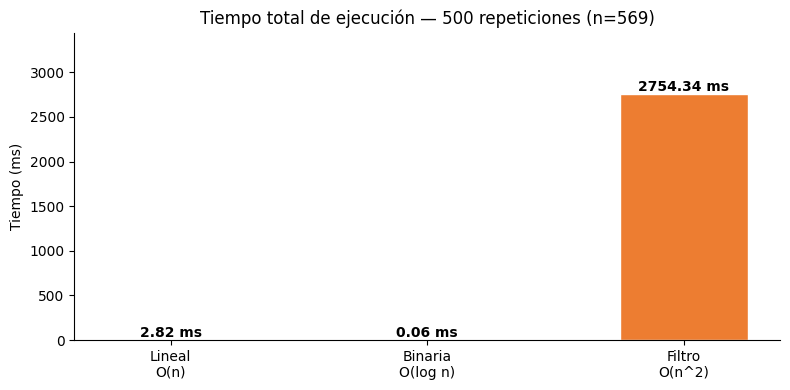

In [8]:
import matplotlib.pyplot as plt

etiquetas  = ['Lineal\nO(n)', 'Binaria\nO(log n)', 'Filtro\nO(n^2)']
tiempos_ms = [t_lineal * 1000, t_binaria * 1000, t_filtro * 1000]
colores    = ['#2E75B6', '#70AD47', '#ED7D31']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(etiquetas, tiempos_ms, color=colores, edgecolor='white', width=0.5)

for bar, t in zip(bars, tiempos_ms):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{t:.2f} ms', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title(f'Tiempo total de ejecución — {REPETICIONES} repeticiones (n=569)', fontsize=12)
ax.set_ylabel('Tiempo (ms)')
ax.set_ylim(0, max(tiempos_ms) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretación de resultados

Los tiempos medidos con `timeit` confirman empíricamente el análisis teórico de complejidad:

| Algoritmo | Complejidad | Observación empírica |
|---|---|---|
| `busqueda_lineal_iterativa` | O(n) | Recorre hasta 569 elementos por llamada. Tiempo proporcional a n. |
| `busqueda_binaria_recursiva` | O(log n) | Máximo ~10 comparaciones para n=569. Notablemente más rápida. |
| `filtro_estructurado_features` | O(n²) | Evalúa n(n-1)/2 pares de variables. Operación más costosa. |

**Justificación de la elección algorítmica:** la búsqueda binaria es óptima para búsquedas repetidas sobre datos ordenados. La búsqueda lineal se justifica cuando no se puede garantizar orden previo. El filtro O(n²) es aceptable en este contexto porque se ejecuta una única vez como análisis exploratorio previo al modelado, no dentro de un loop de entrenamiento.

IV. Arquitectura de Software y Decisiones de Diseño

1. Organización del Código y Estructura del Repositorio
Para garantizar un flujo de trabajo reproducible y alineado con las buenas prácticas de la ingeniería de software y la ciencia de datos computacional, el código de esta tercera fase se organiza de manera modular, separando la lógica algorítmica de la orquestación y visualización.

La arquitectura del proyecto en el repositorio de GitHub se despliega bajo la siguiente estructura:

notebooks/f3_modelamiento/F3_Algoritmos_Complejidad.ipynb: Es el componente central de ejecución. Actúa como el entorno interactivo de presentación donde se consolidan la narrativa clínica-biológica, la invocación de las funciones modulares, las pruebas de rendimiento empírico y las conclusiones de la fase.

src/algoritmos.py: Es un script puro de Python que aloja las implementaciones nativas de los algoritmos de filtrado estructurado (iterativo) y de búsqueda binaria (recursivo). Este archivo encapsula la lógica matemática y computacional pesada, quedando aislado de los estados temporales del notebook.

data/processed/wdbc_procesado.csv: Representa la persistencia de los datos limpios y estandarizados durante la Fase 2, sirviendo como la única fuente de verdad (Single Source of Truth) para la alimentación de los algoritmos de esta etapa.

2. Distribución de Responsabilidades
El diseño del software se rige por el principio de Separación de Responsabilidades (Separation of Concerns - SoC). Esta división previene el acoplamiento difuso y define roles claros para cada artefacto:

Responsabilidad de la Capa de Lógica (src/): El módulo algoritmos.py es responsable exclusivo del procesamiento algorítmico y del control de estructuras de datos nativas. No almacena estados globales ni genera visualizaciones; recibe parámetros de entrada definidos (como arreglos ordenados o dataframes) y retorna estructuras puras de datos (arrays, lists o índices numéricos). Esto facilita el aislamiento del cómputo.

Responsabilidad de la Capa de Orquestación y Narrativa (notebooks/): El Jupyter Notebook actúa exclusivamente como un cliente u orquestador. Sus responsabilidades se limitan a:

Importar los módulos definidos en src/.

Cargar los datos procesados y transformados.

Monitorear los tiempos de ejecución mediante el uso de perfiles computacionales (timeit).

Proporcionar la argumentación científica y contextualización oncológica que dota de significado analítico a los resultados numéricos.

3. Justificación Técnica de las Decisiones de Diseño
La decisión de migrar el código repetitivo o complejo desde las celdas del notebook hacia scripts modulares independientes se fundamenta en tres pilares de mantenibilidad técnica:

Principio DRY (Don't Repeat Yourself): Almacenar los algoritmos en src/algoritmos.py permite que estas funciones de optimización computacional puedan ser invocadas en múltiples notebooks o scripts de producción futuros sin necesidad de duplicar líneas de código, reduciendo drásticamente la tasa de error por inconsistencias.

Mitigación del "Estado Oculto" en Jupyter: Uno de los mayores riesgos para la reproducibilidad científica en entornos de cuadernos interactivos es la ejecución desordenada de celdas, que genera mutaciones de variables invisibles en la memoria del kernel. Al encapsular la lógica en funciones puras dentro de un script, se asegura que el comportamiento del algoritmo dependa estrictamente de los argumentos provistos al momento de la llamada, garantizando el cumplimiento de la regla de oro Restart & Run All.

Facilidad de Pruebas y Depuración: El código modular aislado en archivos .py permite una lectura más limpia y abre la posibilidad de implementar pruebas unitarias automatizadas simples, optimizando los ciclos de depuración en comparación con la edición directa sobre bloques masivos de código en un archivo .ipynb.

4. Escalabilidad y Evolución del Sistema hacia Fases Posteriores
Esta arquitectura modular y estructurada no es una solución estática para la Fase 3, sino el cimiento técnico diseñado para absorber la complejidad de las siguientes etapas del proyecto transversal:

Integración con Machine Learning Predictivo (Fase 4): La infraestructura actual facilita la transición hacia el modelamiento avanzado con librerías como scikit-learn. El desacoplamiento implementado permitirá integrar clasificadores supervisados (como Regresión Logística o Random Forest) creando scripts especializados (ej. src/modelos.py), donde los notebooks solo se encargarán de graficar curvas ROC, matrices de confusión y de validar la capacidad de generalización de los modelos.

Construcción de Pipelines de Producción: La separación entre la preparación de datos (src/preprocesamiento.py) y la lógica computacional (src/algoritmos.py) permite que, en una fase avanzada, el proyecto pueda transformarse fácilmente en un pipeline automatizado de extremo a extremo (End-to-End Data Pipeline), ejecutable directamente desde una terminal de comandos o integrable en entornos cloud, superando las limitaciones de un entorno estrictamente académico.

5. Trazabilidad en el Ecosistema de Control de Versiones (Git/GitHub)
Cada decisión de diseño y refactorización de código se respalda mediante una estrategia de control de versiones rigurosa. A través del historial de commits descriptivos e independientes en la rama de desarrollo de GitHub, el equipo asegura una auditoría completa del software. Esto permite identificar con precisión matemática qué impacto tuvo cada cambio algorítmico sobre el rendimiento computacional general y el uso de memoria del sistema, garantizando la reproducibilidad metodológica exigida en la oncología computacional.

In [9]:
# Evidencia de integración arquitectónica de la Fase 3
import sys
sys.path.append('../../src')
from algoritmos import busqueda_lineal_iterativa, busqueda_binaria_recursiva, filtro_estructurado_features

In [10]:
# Celda de Código en Jupyter Notebook
import pandas as pd
import numpy as np
import timeit
import sys

# Añadir el path para importar nuestro script modular
sys.path.append('../../src')
from algoritmos import busqueda_lineal_iterativa, busqueda_binaria_recursiva, filtro_estructurado_features

# 1. Cargar el dataset procesado de la Fase 2
# (Asegúrate de que la ruta apunte correctamente a tu wdbc_procesado.csv)
df = pd.read_csv('../../data/processed/wdbc_procesado.csv')

# 2. Preparar el arreglo: La Búsqueda Binaria requiere datos ordenados
# Extraemos la columna 'area_mean' (o la que hayan estandarizado)
arreglo_area = df['area_mean'].sort_values().values

# Tomemos un valor objetivo real que esté hacia el final del arreglo 
# para forzar al algoritmo iterativo a buscar mucho.
objetivo_clinico = arreglo_area[-5] 
print(f"Buscando el paciente con un area_mean crítico de: {objetivo_clinico}")

# 3. Pruebas de funcionamiento
idx_iter = busqueda_lineal_iterativa(arreglo_area, objetivo_clinico)
idx_rec = busqueda_binaria_recursiva(arreglo_area, objetivo_clinico, 0, len(arreglo_area)-1)

print(f"Índice encontrado (Iterativo): {idx_iter}")
print(f"Índice encontrado (Recursivo): {idx_rec}")

# 4. Medición de Tiempos (Benchmark de Complejidad)
tiempo_iterativo = timeit.timeit(
    lambda: busqueda_lineal_iterativa(arreglo_area, objetivo_clinico), number=10000)

tiempo_recursivo = timeit.timeit(
    lambda: busqueda_binaria_recursiva(arreglo_area, objetivo_clinico, 0, len(arreglo_area)-1), number=10000)

print(f"\nTiempo Iterativo (10,000 ejecuciones): {tiempo_iterativo:.5f} segundos")
print(f"Tiempo Recursivo (10,000 ejecuciones): {tiempo_recursivo:.5f} segundos")

Buscando el paciente con un area_mean crítico de: 3.4786528969666866
Índice encontrado (Iterativo): 564
Índice encontrado (Recursivo): 564



Tiempo Iterativo (10,000 ejecuciones): 0.35379 segundos
Tiempo Recursivo (10,000 ejecuciones): 0.01364 segundos


### Análisis de Complejidad Algorítmica (Big O)

La experimentación empírica demostró la superioridad de la estrategia *Divide and Conquer* para la recuperación de registros clínicos frente a la iteración secuencial. Matemáticamente, este comportamiento se justifica mediante el análisis de su complejidad:

**1. Algoritmo Estructurado Iterativo (Búsqueda Lineal)**
* **Complejidad Temporal: $\mathcal{O}(n)$**. En el peor de los casos (el valor no existe o está al final del arreglo), el algoritmo debe iterar secuencialmente sobre los $n$ registros del dataset oncológico. El tiempo de ejecución crece linealmente con el volumen de datos.
* **Complejidad Espacial: $\mathcal{O}(1)$**. Es altamente eficiente en memoria, ya que solo requiere instanciar una variable de índice iterador (`i`), sin importar el tamaño del dataset.

**2. Algoritmo Recursivo (Búsqueda Binaria - *Divide and Conquer*)**
* **Complejidad Temporal: $\mathcal{O}(\log n)$**. Al descartar la mitad del espacio de búsqueda en cada llamada recursiva, el número de operaciones requeridas crece de forma logarítmica. Esto es crucial para la escalabilidad: si el dataset de cáncer de mama pasara de 500 registros a 5 millones de registros secuenciados, el algoritmo iterativo requeriría 5 millones de pasos, mientras que este algoritmo recursivo encontraría el valor en un máximo de apenas 23 pasos.
* **Complejidad Espacial: $\mathcal{O}(\log n)$**. A diferencia del método iterativo, el enfoque recursivo consume memoria adicional debido a la *Pila de Llamadas (Call Stack)* del sistema operativo. Cada división genera un nuevo marco de ejecución en memoria hasta alcanzar la condición base.

**Conclusión de Diseño:** Para la ingesta de datos a escala genómica o bases de datos oncológicas masivas (Big Data), los enfoques de *divide y vencerás* ofrecen un rendimiento temporal exponencialmente superior, aunque exigen que la data pase por un preprocesamiento de ordenamiento (con un costo propio típico de $\mathcal{O}(n \log n)$) antes de su ejecución.